# EE/CS 148B HW3: Colab Setup

Run the setup cells first. Experiment cells are commented out when `runs/` artifacts already exist locally — run only the plotting/analysis cells.


## Setup

For **local plotting** (artifacts already in `runs/`): set `USE_DRIVE = False` and point `LOCAL_REPO_ROOT` at this repo.

For **Colab training**: set `USE_DRIVE = True`, use a GPU runtime, and uncomment experiment cells as needed.


In [ ]:
%%capture
!pip -q install -U torch torchvision==2.7.1 transformers datasets "sentence-transformers<4.0" accelerate pillow tqdm matplotlib wandb pyyaml einops pytest pytest-cov pandas
!pip -q install ninja packaging
!pip install "protobuf<5" --force-reinstall

In [ ]:
# !pip install flash-attn --no-build-isolation --no-cache

In [17]:
from pathlib import Path

USE_DRIVE = False
DRIVE_REPO_ROOT = Path('/content/drive/MyDrive/cs148b/hw3/')  # Colab
LOCAL_REPO_ROOT = Path('/home/marco/School/cs148b/hw3')  # edit if needed

if USE_DRIVE:
    from google.colab import drive
    drive.mount('/content/drive')
    REPO_ROOT = DRIVE_REPO_ROOT
else:
    REPO_ROOT = LOCAL_REPO_ROOT

assert REPO_ROOT.exists(), f'Repo root does not exist: {REPO_ROOT}'
print('Using repo:', REPO_ROOT)


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Using repo: /content/drive/MyDrive/cs148b/hw3


In [ ]:
import os
import sys

sys.path.insert(0, str(REPO_ROOT))
sys.path.insert(0, str(REPO_ROOT / 'basics'))
os.environ["PYTHONPATH"] = str(REPO_ROOT)

os.chdir(REPO_ROOT)
print('cwd =', os.getcwd())

cwd = /content/drive/.shortcut-targets-by-id/141wXwJaDiCNP1SWDcuehJctLtn7D0_46/cs148b/hw3


In [ ]:
import json
import re
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import yaml
from PIL import Image
from transformers import set_seed

from basics.lora import apply_lora_to_attention
from basics.text_encoder import FrozenTextEncoder
from basics.vit import ViT
from vlm.clip import ProjectionHeads
from vlm.data import EUROSAT_CLASSES, IMAGENET_MEAN, IMAGENET_STD, build_eurosat_loaders
from vlm.masking import build_causal_mask, build_image_bidir_mask

SEED = 0
set_seed(SEED)

if torch.cuda.is_available():
    torch.backends.cuda.matmul.allow_tf32 = True
    torch.set_float32_matmul_precision('high')

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
RUNS_DIR = Path('runs')
FIGURES_DIR = RUNS_DIR / 'figures'
FIGURES_DIR.mkdir(parents=True, exist_ok=True)


def read_json(path):
    with open(path) as f:
        return json.load(f)


def savefig(name):
    path = FIGURES_DIR / name
    plt.tight_layout()
    plt.savefig(path, dpi=200, bbox_inches='tight')
    plt.show()
    print('saved', path)


def parse_clip_log(log_path):
    rows = {}
    with open(log_path) as f:
        for line in f:
            m = re.search(r'epoch\s+(\d+)/\d+\s+train_loss=([0-9.]+)', line)
            if m:
                rows[int(m.group(1))] = {'epoch': int(m.group(1)), 'train_loss': float(m.group(2))}
            m = re.search(r'epoch\s+(\d+)\s+val_zeroshot_acc=([0-9.]+)', line)
            if m:
                rows.setdefault(int(m.group(1)), {'epoch': int(m.group(1))})['val_zeroshot_acc'] = float(m.group(2))
    return [rows[k] for k in sorted(rows)]


def parse_clip_summary(log_path):
    summary = {}
    with open(log_path) as f:
        for line in f:
            m = re.search(r'epoch\s+(\d+)\s+val_zeroshot_acc=([0-9.]+)', line)
            if m:
                summary['last_val_zeroshot_acc'] = float(m.group(2))
            m = re.search(
                r'pos_encoding=(\S+)\s+best_val_zeroshot_acc=([0-9.]+)\s+'
                r'test_zeroshot_acc=([0-9.]+)\s+extrap_val_zeroshot_acc=([0-9.]+)\s+'
                r'\(eval_img_size=(\d+)\)',
                line,
            )
            if m:
                summary.update(
                    {
                        'pos_encoding': m.group(1),
                        'best_val_zeroshot_acc': float(m.group(2)),
                        'test_zeroshot_acc': float(m.group(3)),
                        'extrap_val_zeroshot_acc': float(m.group(4)),
                        'eval_img_size': int(m.group(5)),
                    }
                )
    return summary


def parse_vit_profile_log(log_path):
    rows = []
    current = {}
    with open(log_path) as f:
        for line in f:
            m = re.search(
                r'Average forward-pass time for size (\d+): ([0-9]+(?:\.[0-9]+)?)\.',
                line,
            )
            if m:
                current = {'patch_size': int(m.group(1)), 'mean_s': float(m.group(2))}
            m = re.search(
                r'Stdev of forward-pass time for size (\d+): ([0-9]+(?:\.[0-9]+)?)\.',
                line,
            )
            if m:
                current['std_s'] = float(m.group(2))
                current['mean_ms'] = current['mean_s'] * 1000
                current['std_ms'] = current['std_s'] * 1000
                current['num_patches'] = (224 // current['patch_size']) ** 2
                rows.append(current)
    return rows


def parse_vlm_log(log_path):
    train_rows, val_rows = [], []
    with open(log_path) as f:
        for line in f:
            m = re.search(r'step\s+(\d+)\s+train_loss=([0-9.]+).*peak_mem_mb=([0-9.]+)', line)
            if m:
                train_rows.append(
                    {
                        'step': int(m.group(1)),
                        'train_loss': float(m.group(2)),
                        'peak_mem_mb': float(m.group(3)),
                    }
                )
            m = re.search(r'step\s+(\d+)\s+val_acc=([0-9.]+)', line)
            if m:
                val_rows.append({'step': int(m.group(1)), 'val_acc': float(m.group(2))})
    return train_rows, val_rows


def summarize_vlm_run(run_dir):
    run_dir = Path(run_dir)
    name = run_dir.name
    summary = {'run_dir': str(run_dir)}

    m = re.match(
        r'vlm_(cls|all_patches|interleaved)_(causal|image_bidir)_([A-D])(?:_\d+)?$',
        name,
    )
    if m:
        summary['injection'] = m.group(1)
        summary['mask_mode'] = m.group(2)
        summary['freeze_config'] = m.group(3)
    else:
        m = re.match(r'vlm_freeze_([A-D])$', name)
        if m:
            summary['injection'] = 'all_patches'
            summary['mask_mode'] = 'image_bidir'
            summary['freeze_config'] = m.group(1)

    if summary.get('injection') == 'cls':
        summary['num_visual_tokens'] = 1
    elif summary.get('injection') in ('all_patches', 'interleaved'):
        summary['num_visual_tokens'] = 65

    best_path = run_dir / 'best.pt'
    log_path = run_dir / 'train.log'
    if best_path.exists():
        ckpt = torch.load(best_path, map_location='cpu', weights_only=True)
        summary.update(
            {
                'injection': ckpt.get('injection', summary.get('injection')),
                'mask_mode': ckpt.get('mask_mode', summary.get('mask_mode')),
                'freeze_config': ckpt.get('freeze_config', summary.get('freeze_config')),
                'best_val_acc': ckpt.get('val_metrics', {}).get('overall'),
                'step': ckpt.get('step'),
            }
        )
        vit_cfg = ckpt.get('vit_config') or ckpt.get('config', {}).get('vit', {})
        if ckpt.get('injection') == 'cls':
            summary['num_visual_tokens'] = 1
        elif vit_cfg:
            summary['num_visual_tokens'] = (vit_cfg['img_size'] // vit_cfg['patch_size']) ** 2 + 1

    if log_path.exists():
        train_rows, val_rows = parse_vlm_log(log_path)
        if train_rows:
            summary['peak_mem_mb'] = max(r['peak_mem_mb'] for r in train_rows)
        if val_rows:
            best_row = max(val_rows, key=lambda r: r['val_acc'])
            summary['best_val_acc'] = max(
                summary.get('best_val_acc', 0.0) or 0.0,
                best_row['val_acc'],
            )
            summary['step'] = best_row['step']
    return summary


print('device =', DEVICE)
if torch.cuda.is_available():
    print('gpu =', torch.cuda.get_device_name(0))
print('HW3 imports and plotting helpers loaded.')

device = cuda
gpu = NVIDIA A100-SXM4-40GB
HW3 imports and plotting helpers loaded.


## 2. ViT

In [ ]:
# RUNS_DIR.mkdir(parents=True, exist_ok=True)
# !python scripts/profile_vit_patch.py | tee runs/vit_patch_profile.log

### §2.4 Patch-size benchmark plot

   patch_size  num_patches      mean_ms      std_ms
0           8          784  6512.402264  108.394651
1          16          196   634.883452   60.328087
2          32           49   130.067290    4.625464


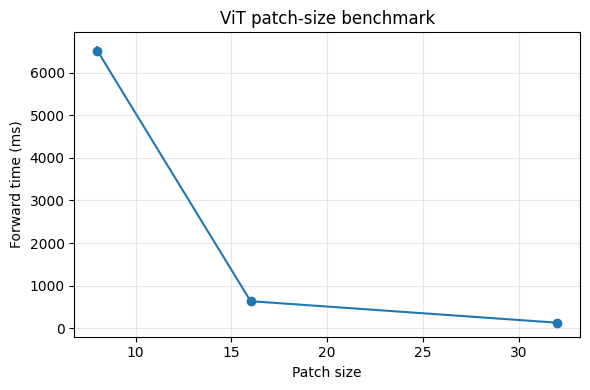

saved runs/figures/vit_patch_benchmark.png


In [ ]:
log_path = RUNS_DIR / 'vit_patch_profile.log'
rows = parse_vit_profile_log(log_path)
assert rows, f'missing {log_path}'

df = pd.DataFrame(rows)
print(df[['patch_size', 'num_patches', 'mean_ms', 'std_ms']])

plt.figure(figsize=(6, 4))
plt.errorbar(df['patch_size'], df['mean_ms'], yerr=df['std_ms'], marker='o')
plt.xlabel('Patch size')
plt.ylabel('Forward time (ms)')
plt.title('ViT patch-size benchmark')
plt.grid(True, alpha=0.3)
savefig('vit_patch_benchmark.png')

## 3. CLIP Pre-training

In [ ]:
# !(mkdir -p runs/clip_eurosat && python scripts/pretrain_clip.py --config configs/clip_eurosat.yaml --pos-enc learned --output-dir runs/clip_eurosat | tee runs/clip_eurosat/train.log)

### §3.3 CLIP training curves

In [ ]:
# nvm did this in wandb
# history = parse_clip_log(RUNS_DIR / 'clip_eurosat' / 'train.log')
# df = pd.DataFrame(history)

# plt.figure(figsize=(6, 4))
# plt.plot(df['epoch'], df['train_loss'], marker='o')
# plt.xlabel('Epoch')
# plt.ylabel('Train loss')
# plt.title('CLIP training loss')
# plt.grid(True, alpha=0.3)
# savefig('clip_train_loss.png')

# plt.figure(figsize=(6, 4))
# plt.plot(df['epoch'], df['val_zeroshot_acc'], marker='o')
# plt.xlabel('Epoch')
# plt.ylabel('Val zero-shot accuracy')
# plt.title('CLIP zero-shot validation accuracy')
# plt.grid(True, alpha=0.3)
# savefig('clip_val_zeroshot_acc.png')

### §3.3 Zero-shot qualitative examples

5 correctly classified and 5 incorrectly classified validation images, with top-3 predictions for the mistakes.

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

data/test-00000-of-00001.parquet:   0%|          | 0.00/34.8M [00:00<?, ?B/s]

data/validation-00000-of-00001.parquet:   0%|          | 0.00/34.8M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/16200 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/5400 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/5400 [00:00<?, ? examples/s]

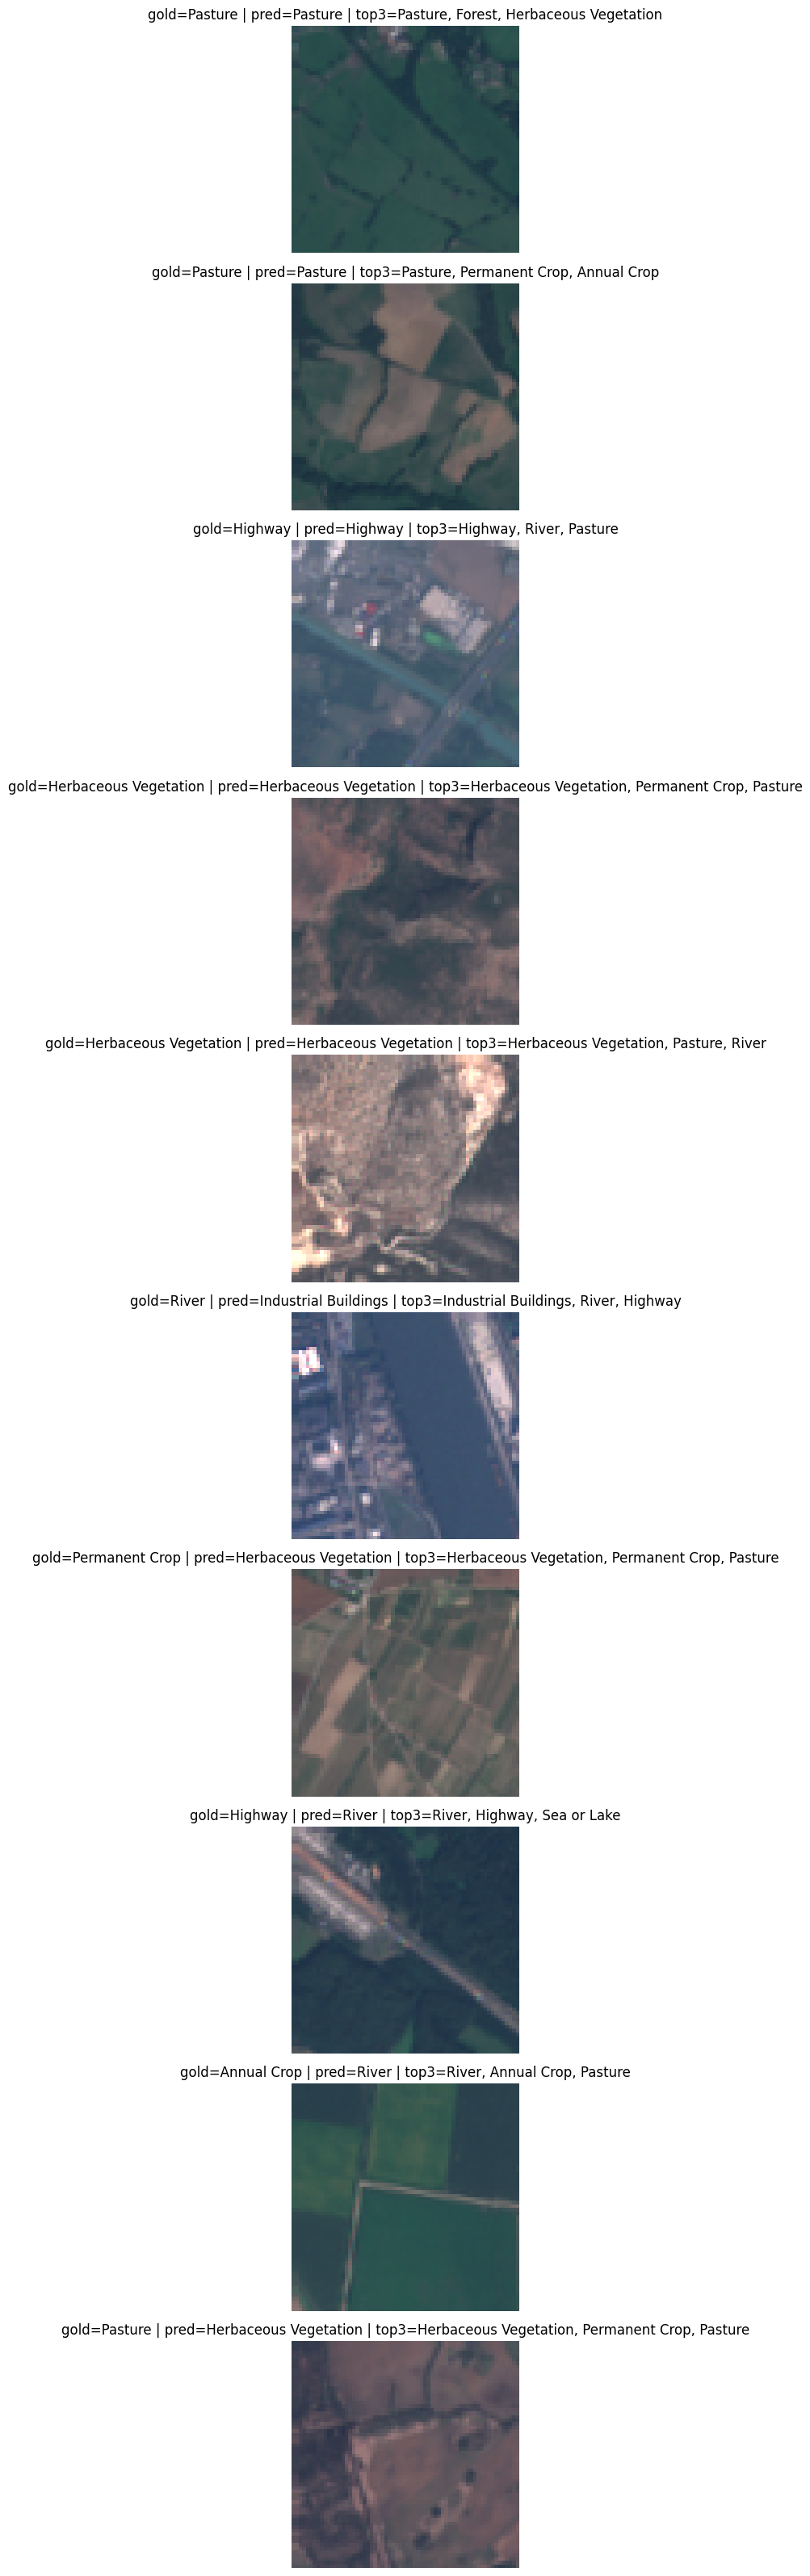

saved runs/figures/clip_qualitative_examples.png
Incorrect examples:
  gold=River pred=Industrial Buildings top3=['Industrial Buildings', 'River', 'Highway']
  gold=Permanent Crop pred=Herbaceous Vegetation top3=['Herbaceous Vegetation', 'Permanent Crop', 'Pasture']
  gold=Highway pred=River top3=['River', 'Highway', 'Sea or Lake']
  gold=Annual Crop pred=River top3=['River', 'Annual Crop', 'Pasture']
  gold=Pasture pred=Herbaceous Vegetation top3=['Herbaceous Vegetation', 'Permanent Crop', 'Pasture']


In [ ]:
# Already generated on Colab — see runs/figures/clip_qualitative_examples.png
# num_correct, num_incorrect = 5, 5
# ckpt_path = RUNS_DIR / 'clip_eurosat' / 'best.pt'

# with open('configs/clip_eurosat.yaml') as f:
#     cfg = yaml.safe_load(f)
# vit_cfg = cfg['vit']

# ckpt = torch.load(ckpt_path, map_location=DEVICE, weights_only=True)
# vit = ViT(**vit_cfg).to(DEVICE)
# text_encoder = FrozenTextEncoder(cfg['text_encoder']['model_name']).to(DEVICE)
# heads = ProjectionHeads(vit_cfg['d_model'], text_encoder.embedding_dim, cfg['projection']['d_proj']).to(DEVICE)
# vit.load_state_dict(ckpt['vit'])
# heads.load_state_dict(ckpt['projection_heads'])
# vit.eval(); heads.eval(); text_encoder.eval()

# _, val_dl, _ = build_eurosat_loaders(img_size=vit_cfg['img_size'], batch_size=64, num_workers=2)
# class_prompts = [f'a satellite image of {name}' for name in EUROSAT_CLASSES]

# correct_rows, incorrect_rows = [], []
# with torch.no_grad():
#     text_embeds = text_encoder(class_prompts)
#     _, class_proj = heads(torch.zeros(len(class_prompts), vit.d_model, device=DEVICE), text_embeds)
#     for images, captions in val_dl:
#         images = images.to(DEVICE)
#         labels = torch.tensor([class_prompts.index(c) for c in captions], device=DEVICE)
#         image_features = vit(images)
#         image_proj, _ = heads(image_features, torch.zeros(1, text_embeds.shape[-1], device=DEVICE))
#         sims = image_proj @ class_proj.T
#         top3_scores, top3_idx = sims.topk(k=3, dim=-1)
#         preds = top3_idx[:, 0]
#         for i in range(images.shape[0]):
#             row = {
#                 'image': images[i].cpu(),
#                 'gold': EUROSAT_CLASSES[labels[i].item()],
#                 'pred': EUROSAT_CLASSES[preds[i].item()],
#                 'top3': [EUROSAT_CLASSES[j] for j in top3_idx[i].tolist()],
#                 'top3_scores': [float(s) for s in top3_scores[i].tolist()],
#             }
#             if preds[i].item() == labels[i].item():
#                 if len(correct_rows) < num_correct:
#                     correct_rows.append(row)
#             elif len(incorrect_rows) < num_incorrect:
#                 incorrect_rows.append(row)
#         if len(correct_rows) >= num_correct and len(incorrect_rows) >= num_incorrect:
#             break

# rows = correct_rows + incorrect_rows
# mean = torch.tensor(IMAGENET_MEAN).view(3, 1, 1)
# std = torch.tensor(IMAGENET_STD).view(3, 1, 1)
# fig, axes = plt.subplots(len(rows), 1, figsize=(7, 3.2 * len(rows)))
# if len(rows) == 1:
#     axes = [axes]
# for ax, row in zip(axes, rows):
#     img = (row['image'] * std + mean).clamp(0, 1).permute(1, 2, 0).numpy()
#     ax.imshow(img)
#     ax.set_title(f"gold={row['gold']} | pred={row['pred']} | top3={', '.join(row['top3'])}")
#     ax.axis('off')
# savefig('clip_qualitative_examples.png')

# print('Incorrect examples:')
# for row in incorrect_rows:
#     print(f"  gold={row['gold']} pred={row['pred']} top3={row['top3']}")

## 4. RESISC Experiments

### Linear Probe vs LoRA vs Full Finetuning

In [ ]:
# !python scripts/finetune_resisc.py --config configs/lora_resisc.yaml --method linear_probe --pretrained runs/clip_eurosat/best.pt --output-dir runs/resisc_linear_probe

In [ ]:
# !python scripts/finetune_resisc.py --config configs/lora_resisc.yaml --method lora --rank 8 --alpha 16 --pretrained runs/clip_eurosat/best.pt --output-dir runs/resisc_lora_rank8

In [ ]:
# !python scripts/finetune_resisc.py --config configs/lora_resisc.yaml --method full_ft --pretrained runs/clip_eurosat/best.pt --output-dir runs/resisc_full_ft

### §4.1 LoRA parameter counts and §4.2 method comparison

total params: 10,995,840
trainable params: 258,048
ratio: 0.023468
         method  test_acc  trainable_params  peak_mem_gb  wall_clock_min
0  linear_probe  0.371429             17325     0.233667        1.371692
1       lora_r8  0.423333            275373     1.120707        3.176776
2       full_ft  0.623651          10755117     1.625343        3.532173


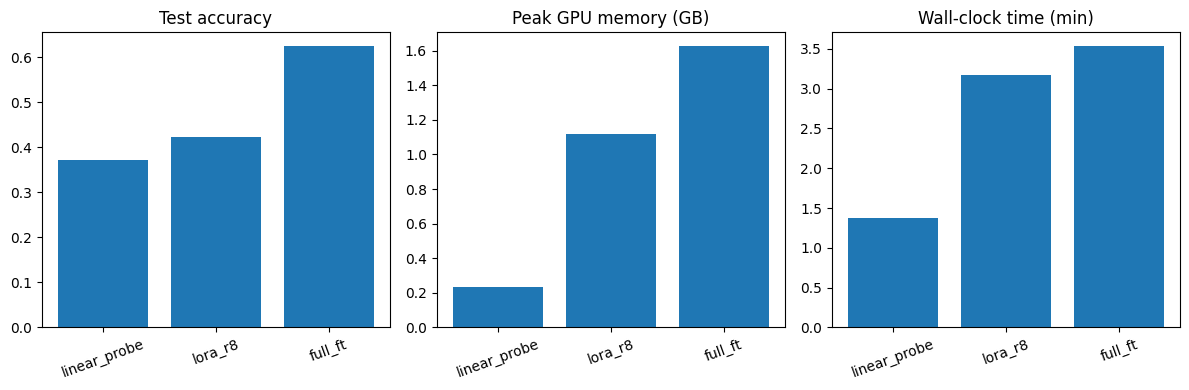

saved runs/figures/resisc_method_compare.png


In [ ]:
with open('configs/clip_eurosat.yaml') as f:
    cfg = yaml.safe_load(f)
vit = ViT(**cfg['vit'])
apply_lora_to_attention(vit, rank=8, alpha=16.0)
total = sum(p.numel() for p in vit.parameters())
trainable = sum(p.numel() for p in vit.parameters() if p.requires_grad)
print(f'total params: {total:,}')
print(f'trainable params: {trainable:,}')
print(f'ratio: {trainable / total:.6f}')

runs = {
    'linear_probe': RUNS_DIR / 'resisc_linear_probe' / 'metrics.json',
    'lora_r8': RUNS_DIR / 'resisc_lora_rank8' / 'metrics.json',
    'full_ft': RUNS_DIR / 'resisc_full_ft' / 'metrics.json',
}
rows = []
for label, path in runs.items():
    m = read_json(path)
    rows.append(
        {
            'method': label,
            'test_acc': m['final_test_acc'],
            'trainable_params': m['trainable_params'],
            'peak_mem_gb': m['peak_memory_bytes'] / (1024 ** 3),
            'wall_clock_min': m['wall_clock_seconds'] / 60,
        }
    )
df = pd.DataFrame(rows)
print(df)

fig, axes = plt.subplots(1, 3, figsize=(12, 4))
axes[0].bar(df['method'], df['test_acc'])
axes[0].set_title('Test accuracy')
axes[1].bar(df['method'], df['peak_mem_gb'])
axes[1].set_title('Peak GPU memory (GB)')
axes[2].bar(df['method'], df['wall_clock_min'])
axes[2].set_title('Wall-clock time (min)')
for ax in axes:
    ax.tick_params(axis='x', rotation=20)
savefig('resisc_method_compare.png')

### LoRA Rank Sweep

In [ ]:
# !python scripts/finetune_resisc.py --config configs/lora_resisc.yaml --method lora --rank 1 --alpha 2 --pretrained runs/clip_eurosat/best.pt --output-dir runs/resisc_rank_1
# !python scripts/finetune_resisc.py --config configs/lora_resisc.yaml --method lora --rank 2 --alpha 4 --pretrained runs/clip_eurosat/best.pt --output-dir runs/resisc_rank_2
# !python scripts/finetune_resisc.py --config configs/lora_resisc.yaml --method lora --rank 4 --alpha 8 --pretrained runs/clip_eurosat/best.pt --output-dir runs/resisc_rank_4
# !python scripts/finetune_resisc.py --config configs/lora_resisc.yaml --method lora --rank 8 --alpha 16 --pretrained runs/clip_eurosat/best.pt --output-dir runs/resisc_rank_8
# !python scripts/finetune_resisc.py --config configs/lora_resisc.yaml --method lora --rank 16 --alpha 32 --pretrained runs/clip_eurosat/best.pt --output-dir runs/resisc_rank_16
# !python scripts/finetune_resisc.py --config configs/lora_resisc.yaml --method lora --rank 32 --alpha 64 --pretrained runs/clip_eurosat/best.pt --output-dir runs/resisc_rank_32
# !python scripts/finetune_resisc.py --config configs/lora_resisc.yaml --method lora --rank 64 --alpha 128 --pretrained runs/clip_eurosat/best.pt --output-dir runs/resisc_rank_64

### §4.2 LoRA rank sweep plot

   rank  test_acc
0     1  0.336667
1     2  0.359841
2     4  0.381429
3     8  0.429683
4    16  0.452381
5    32  0.482063
6    64  0.521587


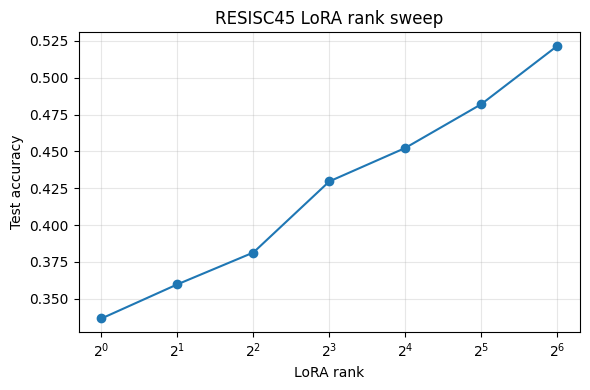

saved runs/figures/resisc_lora_rank_sweep.png


In [ ]:
rows = []
for rank in [1, 2, 4, 8, 16, 32, 64]:
    m = read_json(RUNS_DIR / 'resisc_rank_sweep' / f'rank_{rank}' / 'metrics.json')
    rows.append({'rank': rank, 'test_acc': m['final_test_acc']})
df = pd.DataFrame(rows)
print(df)

plt.figure(figsize=(6, 4))
plt.plot(df['rank'], df['test_acc'], marker='o')
plt.xscale('log', base=2)
plt.xlabel('LoRA rank')
plt.ylabel('Test accuracy')
plt.title('RESISC45 LoRA rank sweep')
plt.grid(True, alpha=0.3)
savefig('resisc_lora_rank_sweep.png')

## 5. VLM Training

In [ ]:
# !python scripts/download_clevr.py

CLEVR-mini already present at data/clevr_mini. Nothing to do.


### Injection Comparison (2000 steps)

In [ ]:
# !(mkdir -p runs/vlm_all_patches_image_bidir_A && python scripts/train_vlm.py --config configs/vlm_clevr.yaml --pretrained-vit runs/clip_eurosat/best.pt --injection all_patches --mask-mode image_bidir --freeze-config A --output-dir runs/vlm_all_patches_image_bidir_A | tee runs/vlm_all_patches_image_bidir_A/train.log)

config.json: 100% 846/846 [00:00<00:00, 783kB/s]
tokenizer_config.json: 3.76kB [00:00, 15.9MB/s]
tokenizer.json: 2.10MB [00:00, 148MB/s]
special_tokens_map.json: 100% 655/655 [00:00<00:00, 4.16MB/s]
Using eager decoder attention because image_bidir needs a custom 4D mask.
model.safetensors: 100% 724M/724M [00:03<00:00, 189MB/s]
Loading weights: 100% 290/290 [00:00<00:00, 1008.14it/s, Materializing param=model.norm.weight]
generation_config.json: 100% 132/132 [00:00<00:00, 914kB/s]
train_vlm:  10% 199/2000 [20:12<2:09:35,  4.32s/it, grad=46.50, loss=2.6095, lr=1.00e-04, mem_mb=7663] step 00025 train_loss=6.4704 grad_norm=162.0000 lr=1.40e-05 peak_mem_mb=7594
step 00050 train_loss=5.8970 grad_norm=286.0000 lr=2.60e-05 peak_mem_mb=7663
step 00075 train_loss=5.4152 grad_norm=195.0000 lr=3.80e-05 peak_mem_mb=7663
step 00100 train_loss=4.9177 grad_norm=150.0000 lr=5.20e-05 peak_mem_mb=7663
step 00125 train_loss=4.4807 grad_norm=134.0000 lr=6.40e-05 peak_mem_mb=7663
step 00150 train_loss=3.90

In [ ]:
# !(mkdir -p runs/vlm_cls_image_bidir_A && python scripts/train_vlm.py --config configs/vlm_clevr.yaml --pretrained-vit runs/clip_eurosat/best.pt --injection cls --mask-mode image_bidir --freeze-config A --output-dir runs/vlm_cls_image_bidir_A | tee runs/vlm_cls_image_bidir_A/train.log)

Using eager decoder attention because image_bidir needs a custom 4D mask.
Loading weights: 100% 290/290 [00:00<00:00, 999.56it/s, Materializing param=model.norm.weight]
train_vlm:  10% 199/2000 [00:48<05:08,  5.83it/s, grad=18.00, loss=5.7611, lr=1.00e-04, mem_mb=3562] step 00025 train_loss=6.8569 grad_norm=128.0000 lr=1.40e-05 peak_mem_mb=3362
step 00050 train_loss=6.8174 grad_norm=17.7500 lr=2.60e-05 peak_mem_mb=3394
step 00075 train_loss=6.7046 grad_norm=68.5000 lr=3.80e-05 peak_mem_mb=3394
step 00100 train_loss=6.4425 grad_norm=29.0000 lr=5.20e-05 peak_mem_mb=3394
step 00125 train_loss=6.5405 grad_norm=85.5000 lr=6.40e-05 peak_mem_mb=3520
step 00150 train_loss=6.3774 grad_norm=59.0000 lr=7.60e-05 peak_mem_mb=3520
step 00175 train_loss=6.0677 grad_norm=111.0000 lr=8.80e-05 peak_mem_mb=3562
step 00200 train_loss=5.7611 grad_norm=18.0000 lr=1.00e-04 peak_mem_mb=3562
train_vlm:  20% 399/2000 [02:00<04:17,  6.22it/s, grad=39.75, loss=2.5719, lr=9.98e-05, mem_mb=3562]step 00200 val_acc=0

In [ ]:
# !(mkdir -p runs/vlm_interleaved_image_bidir_A && python scripts/train_vlm.py --config configs/vlm_clevr.yaml --pretrained-vit runs/clip_eurosat/best.pt --injection interleaved --mask-mode image_bidir --freeze-config A --output-dir runs/vlm_interleaved_image_bidir_A | tee runs/vlm_interleaved_image_bidir_A/train.log)

Using eager decoder attention because image_bidir needs a custom 4D mask.
Loading weights: 100% 290/290 [00:00<00:00, 910.69it/s, Materializing param=model.norm.weight]
The new embeddings will be initialized from a multivariate normal distribution that has old embeddings' mean and covariance. As described in this article: https://nlp.stanford.edu/~johnhew/vocab-expansion.html. To disable this, use `mean_resizing=False`
train_vlm:  10% 199/2000 [00:38<05:34,  5.38it/s, grad=20.12, loss=1.7737, lr=1.00e-04, mem_mb=7675]step 00025 train_loss=5.0002 grad_norm=103.5000 lr=1.40e-05 peak_mem_mb=7565
step 00050 train_loss=4.7594 grad_norm=88.0000 lr=2.60e-05 peak_mem_mb=7565
step 00075 train_loss=4.3222 grad_norm=61.0000 lr=3.80e-05 peak_mem_mb=7675
step 00100 train_loss=3.7785 grad_norm=33.2500 lr=5.20e-05 peak_mem_mb=7675
step 00125 train_loss=3.2620 grad_norm=66.5000 lr=6.40e-05 peak_mem_mb=7675
step 00150 train_loss=2.6086 grad_norm=37.7500 lr=7.60e-05 peak_mem_mb=7675
step 00175 train_los

### §5.4 Injection comparison table/plot

     injection  num_visual_tokens  best_val_acc  peak_mem_mb
0          cls                  1         0.364       3562.0
1  all_patches                 65         0.426       7663.0
2  interleaved                 65         0.452       7737.0


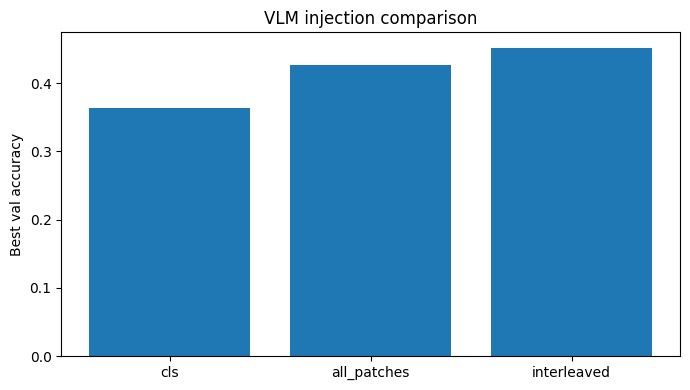

saved runs/figures/vlm_injection_compare.png


In [ ]:
runs = [
    RUNS_DIR / 'vlm_cls_image_bidir_A',
    RUNS_DIR / 'vlm_all_patches_image_bidir_A',
    RUNS_DIR / 'vlm_interleaved_image_bidir_A',
]
rows = [summarize_vlm_run(r) for r in runs]
df = pd.DataFrame(rows)
print(df[['injection', 'num_visual_tokens', 'best_val_acc', 'peak_mem_mb']])

plt.figure(figsize=(7, 4))
plt.bar(df['injection'], df['best_val_acc'])
plt.ylabel('Best val accuracy')
plt.title('VLM injection comparison')
savefig('vlm_injection_compare.png')

### Masking Comparison (500 steps, all_patches)

In [ ]:
# !(mkdir -p runs/vlm_all_patches_causal_A_500 && python scripts/train_vlm.py --config configs/vlm_clevr_500.yaml --pretrained-vit runs/clip_eurosat/best.pt --injection all_patches --mask-mode causal --freeze-config A --output-dir runs/vlm_all_patches_causal_A_500 | tee runs/vlm_all_patches_causal_A_500/train.log)
# !(mkdir -p runs/vlm_all_patches_image_bidir_A_500 && python scripts/train_vlm.py --config configs/vlm_clevr_500.yaml --pretrained-vit runs/clip_eurosat/best.pt --injection all_patches --mask-mode image_bidir --freeze-config A --output-dir runs/vlm_all_patches_image_bidir_A_500 | tee runs/vlm_all_patches_image_bidir_A_500/train.log)

tokenizer_config.json: 3.76kB [00:00, 19.2MB/s]
vocab.json: 801kB [00:00, 20.6MB/s]
merges.txt: 466kB [00:00, 54.6MB/s]
tokenizer.json: 2.10MB [00:00, 122MB/s]
special_tokens_map.json: 100% 655/655 [00:00<00:00, 5.81MB/s]
config.json: 100% 846/846 [00:00<00:00, 7.70MB/s]
2026-05-22 06:13:38.373531: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1779430418.391914   17135 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1779430418.397296   17135 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1779430418.411592   17135 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more t

### §5.5 Attention mask diagrams and masking comparison

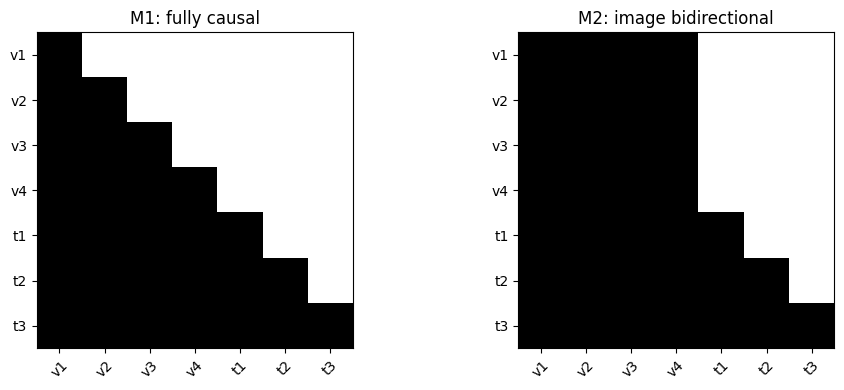

saved runs/figures/vlm_attention_masks.png
     mask_mode  best_val_acc  peak_mem_mb
0          NaN           NaN          NaN
1  image_bidir         0.326       7677.0


TypeError: 'value' must be an instance of str or bytes, not a float

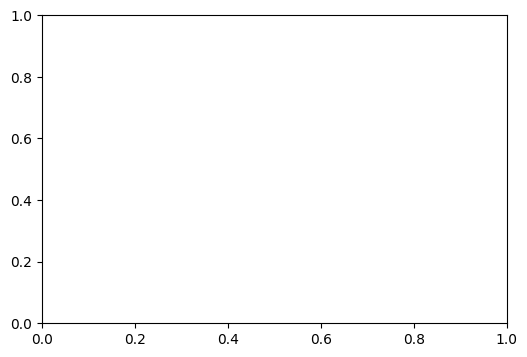

In [ ]:
n_visual, n_text = 4, 3
seq_len = n_visual + n_text
dtype = torch.float32
causal = build_causal_mask(seq_len, device='cpu', dtype=dtype)[0, 0].numpy()
bidir = build_image_bidir_mask(n_visual, n_text, device='cpu', dtype=dtype)[0, 0].numpy()
labels = [f'v{i+1}' for i in range(n_visual)] + [f't{i+1}' for i in range(n_text)]

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, mat, title in [
    (axes[0], (causal >= 0).astype(float), 'M1: fully causal'),
    (axes[1], (bidir >= 0).astype(float), 'M2: image bidirectional'),
]:
    ax.imshow(mat, cmap='Greys', vmin=0, vmax=1)
    ax.set_xticks(range(seq_len), labels, rotation=45)
    ax.set_yticks(range(seq_len), labels)
    ax.set_title(title)
savefig('vlm_attention_masks.png')

runs = [
    RUNS_DIR / 'vlm_all_patches_causal_A_500',
    RUNS_DIR / 'vlm_all_patches_image_bidir_A_500',
]
rows = [summarize_vlm_run(r) for r in runs]
df = pd.DataFrame(rows)
print(df[['mask_mode', 'best_val_acc', 'peak_mem_mb']])

plt.figure(figsize=(6, 4))
plt.bar(df['mask_mode'], df['best_val_acc'])
plt.ylabel('Best val accuracy')
plt.title('VLM masking comparison (500 steps)')
savefig('vlm_masking_compare.png')

### Freezing Comparison (1500 steps, all_patches + image_bidir)

In [ ]:
# !(mkdir -p runs/vlm_freeze_A && python scripts/train_vlm.py --config configs/vlm_clevr_1500.yaml --pretrained-vit runs/clip_eurosat/best.pt --injection all_patches --mask-mode image_bidir --freeze-config A --output-dir runs/vlm_freeze_A | tee runs/vlm_freeze_A/train.log)
# !(mkdir -p runs/vlm_freeze_B && python scripts/train_vlm.py --config configs/vlm_clevr_1500.yaml --pretrained-vit runs/clip_eurosat/best.pt --injection all_patches --mask-mode image_bidir --freeze-config B --output-dir runs/vlm_freeze_B | tee runs/vlm_freeze_B/train.log)
# !(mkdir -p runs/vlm_freeze_C && python scripts/train_vlm.py --config configs/vlm_clevr_1500.yaml --pretrained-vit runs/clip_eurosat/best.pt --injection all_patches --mask-mode image_bidir --freeze-config C --output-dir runs/vlm_freeze_C | tee runs/vlm_freeze_C/train.log)
# !(mkdir -p runs/vlm_freeze_D && python scripts/train_vlm.py --config configs/vlm_clevr_1500.yaml --pretrained-vit runs/clip_eurosat/best.pt --injection all_patches --mask-mode image_bidir --freeze-config D --output-dir runs/vlm_freeze_D | tee runs/vlm_freeze_D/train.log)

2026-05-22 07:30:25.303753: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1779435025.322222   36090 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1779435025.327964   36090 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1779435025.342681   36090 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1779435025.342708   36090 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1779435025.342711   36090 computation_placer.cc:177] computation placer alr

### §5.6 Freezing comparison table/plot

  freeze_config  best_val_acc  peak_mem_mb
0             A         0.436       7677.0
1             B         0.420       7901.0
2             C         0.450      11404.0
3             D         0.484      11927.0


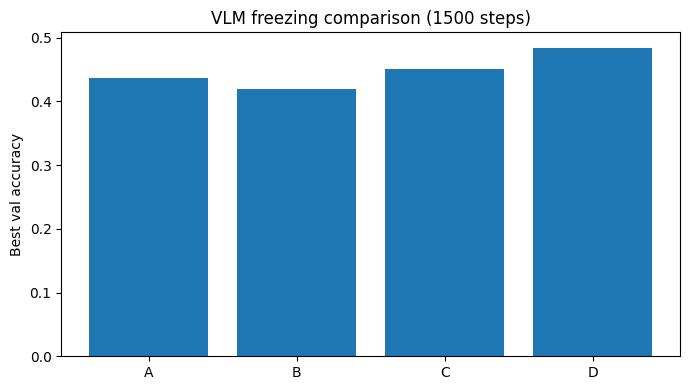

saved runs/figures/vlm_freezing_compare.png


In [10]:
runs = [RUNS_DIR / f'vlm_freeze_{c}' for c in ['A', 'B', 'C', 'D']]
rows = [summarize_vlm_run(r) for r in runs]
df = pd.DataFrame(rows)
print(df[['freeze_config', 'best_val_acc', 'peak_mem_mb']])

plt.figure(figsize=(7, 4))
plt.bar(df['freeze_config'], df['best_val_acc'])
plt.ylabel('Best val accuracy')
plt.title('VLM freezing comparison (1500 steps)')
savefig('vlm_freezing_compare.png')

### §5.7 Qualitative Evaluation

Run this after implementing `scripts/eval_vlm.py`. Update the checkpoint path if your best run differs.

In [18]:
# !python scripts/eval_vlm.py --checkpoint runs/vlm_all_patches_image_bidir_A/best.pt --num-examples 10 --save-images --output-dir runs/vlm_qualitative

2026-05-22 08:24:06.646973: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1779438246.665362   52023 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1779438246.670915   52023 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1779438246.685196   52023 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1779438246.685220   52023 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1779438246.685223   52023 computation_placer.cc:177] computation placer alr

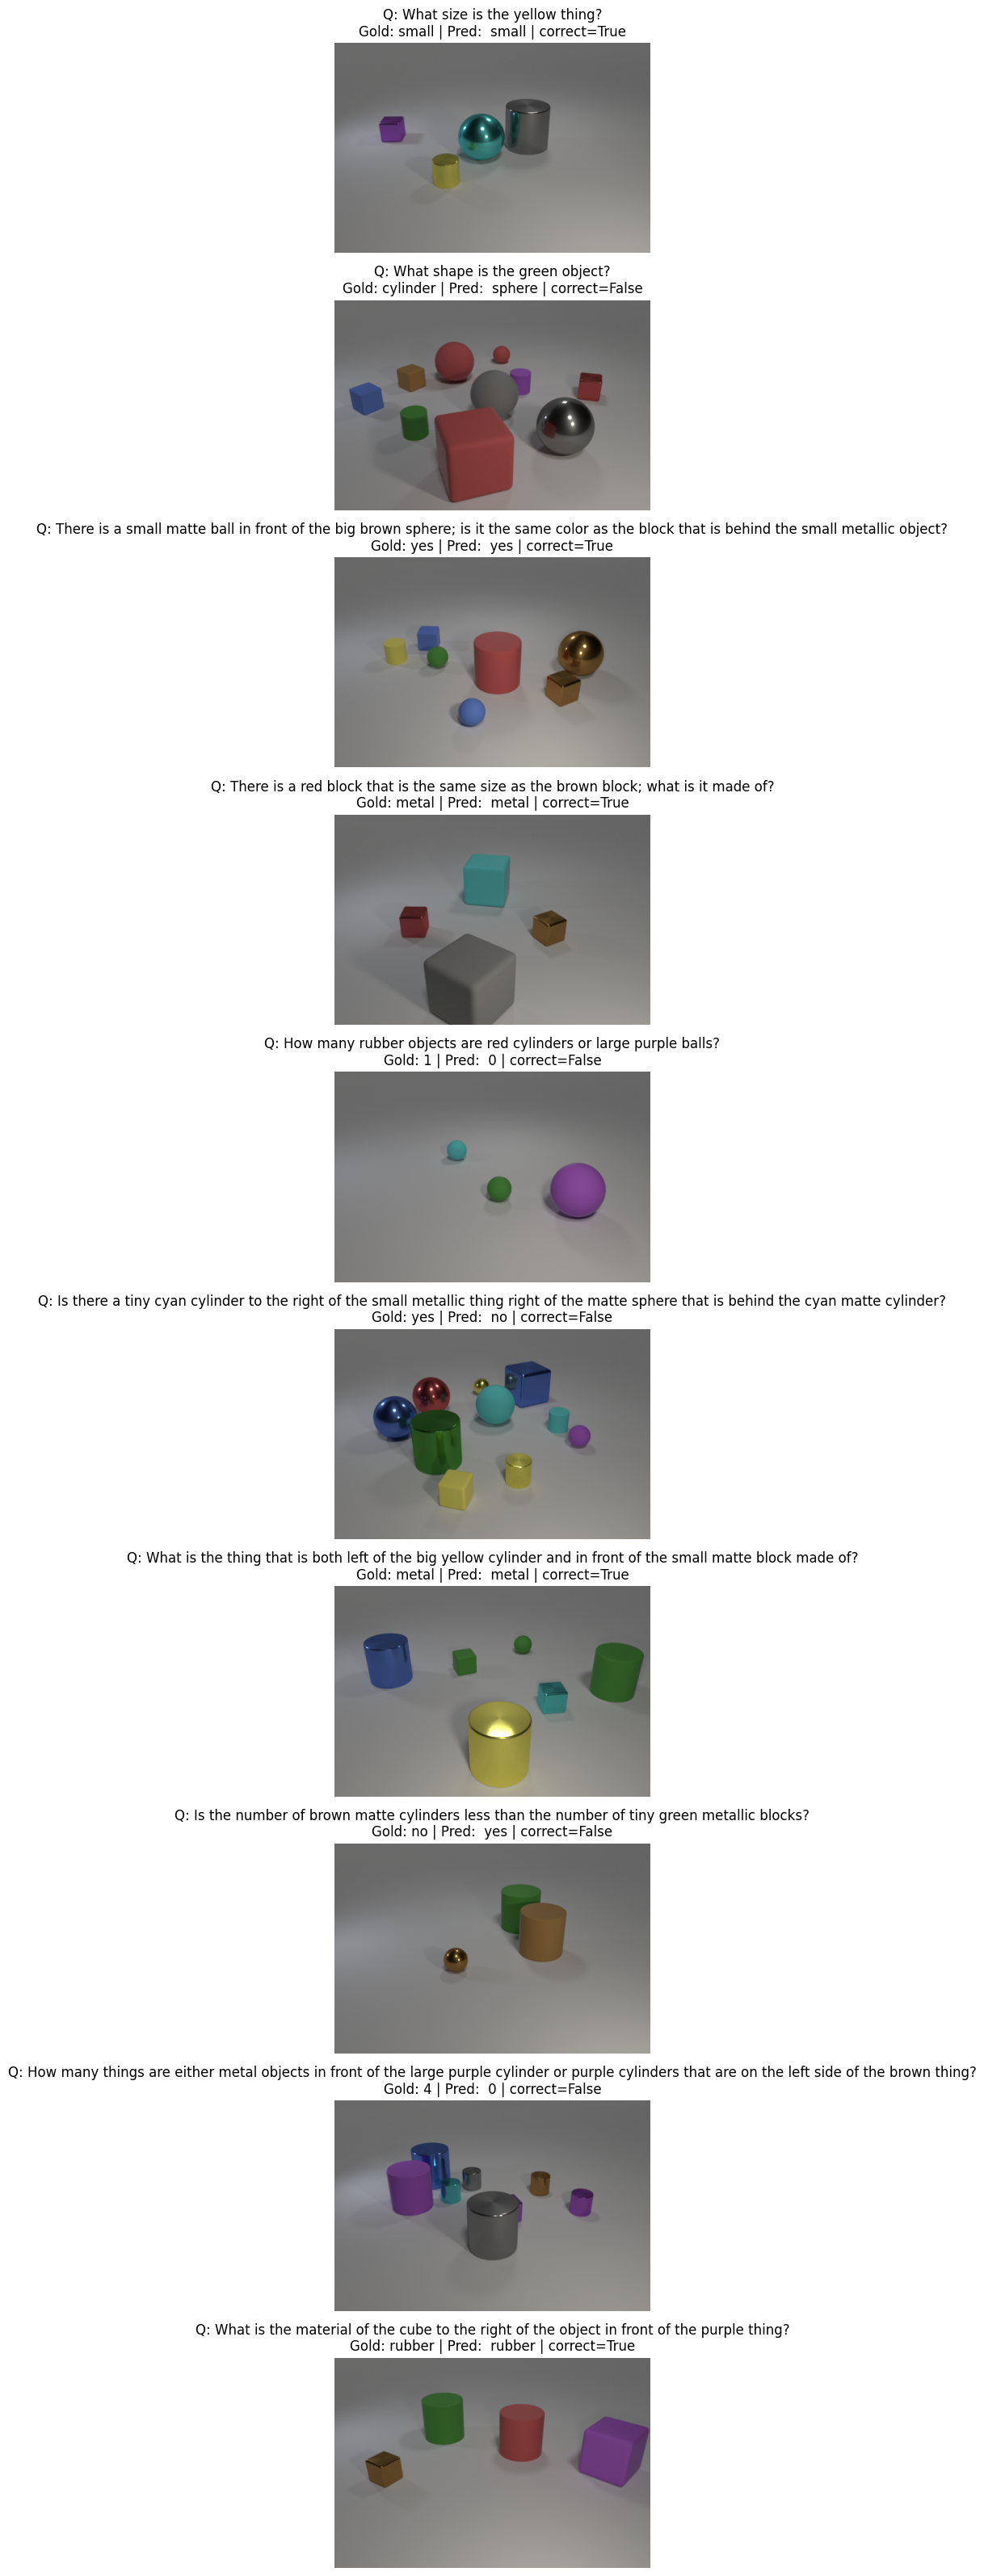

saved runs/figures/vlm_qualitative_examples.png


In [19]:
# Already generated on Colab — see runs/figures/vlm_qualitative_examples.png
# (examples.jsonl + runs/vlm_qualitative/images/ also on disk)
# examples_path = RUNS_DIR / 'vlm_qualitative' / 'examples.jsonl'
# assert examples_path.exists(), f'missing {examples_path} — implement scripts/eval_vlm.py first'

# rows = [json.loads(line) for line in open(examples_path)]
# fig, axes = plt.subplots(len(rows), 1, figsize=(8, 3.2 * len(rows)))
# if len(rows) == 1:
#     axes = [axes]
# for ax, row in zip(axes, rows):
#     img_path = row.get('saved_image')
#     if img_path and Path(img_path).exists():
#         ax.imshow(Image.open(img_path))
#     ax.set_title(
#         f"Q: {row['question']}\nGold: {row['gold']} | Pred: {row['prediction']} | correct={row['correct']}"
#     )
#     ax.axis('off')
# savefig('vlm_qualitative_examples.png')

## 6. Positional Encodings and RoPE

In [13]:
# !python -m pytest -k test_rope -q

......                                                                   [100%]
6 passed, 12 deselected in 3.75s


### §6.1 Verify RoPE preserves vector norms

In [14]:
from basics.rope import RoPE1D, RoPE2D

torch.manual_seed(SEED)
head_dim, max_seq, grid = 64, 32, 12
x1d = torch.randn(4, 6, 16, head_dim)
pos = torch.arange(16)
out1d = RoPE1D(head_dim, max_seq)(x1d, pos)
diff1d = (x1d.norm(dim=-1) - out1d.norm(dim=-1)).abs()
print('RoPE1D max |Δnorm| =', diff1d.max().item())

x2d = torch.randn(2, 4, 20, head_dim)
x_coords = torch.randint(0, grid, (20,))
y_coords = torch.randint(0, grid, (20,))
out2d = RoPE2D(head_dim, grid)(x2d, x_coords, y_coords)
diff2d = (x2d.norm(dim=-1) - out2d.norm(dim=-1)).abs()
print('RoPE2D max |Δnorm| =', diff2d.max().item())

RoPE1D max |Δnorm| = 9.5367431640625e-07
RoPE2D max |Δnorm| = 9.5367431640625e-07


### §6.1–6.2 CLIP with 1D and 2D RoPE

Section 3 already trains the learned-PE baseline at `runs/clip_eurosat`. Retrain with RoPE variants below (20 epochs each).

In [15]:
# !(mkdir -p runs/clip_eurosat_rope_1d && python scripts/pretrain_clip.py --config configs/clip_eurosat.yaml --pos-enc rope_1d --max-img-size 96 --eval-img-size 96 --output-dir runs/clip_eurosat_rope_1d | tee runs/clip_eurosat_rope_1d/train.log)
# !(mkdir -p runs/clip_eurosat_rope_2d && python scripts/pretrain_clip.py --config configs/clip_eurosat.yaml --pos-enc rope_2d --max-img-size 96 --eval-img-size 96 --output-dir runs/clip_eurosat_rope_2d | tee runs/clip_eurosat_rope_2d/train.log)

README.md: 3.38kB [00:00, 15.9MB/s]
data/train-00000-of-00001.parquet: 100% 105M/105M [00:01<00:00, 71.3MB/s]
data/test-00000-of-00001.parquet: 100% 34.8M/34.8M [00:00<00:00, 55.6MB/s]
data/validation-00000-of-00001.parquet: 100% 34.8M/34.8M [00:00<00:00, 60.3MB/s]
Generating train split: 100% 16200/16200 [00:00<00:00, 71296.90 examples/s]
Generating test split: 100% 5400/5400 [00:00<00:00, 89931.12 examples/s]
Generating validation split: 100% 5400/5400 [00:00<00:00, 96171.86 examples/s]
2026-05-22 08:13:47.236023: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1779437627.254447   47646 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1779437627.259944   47646 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factor

### §6.1–6.2 Length extrapolation comparison (64 → 96 px)

  pos_encoding  best_val_zeroshot_acc  extrap_val_zeroshot_acc  eval_img_size
0      rope_1d                 0.9066                   0.8064             96
1      rope_2d                 0.9090                   0.8210             96


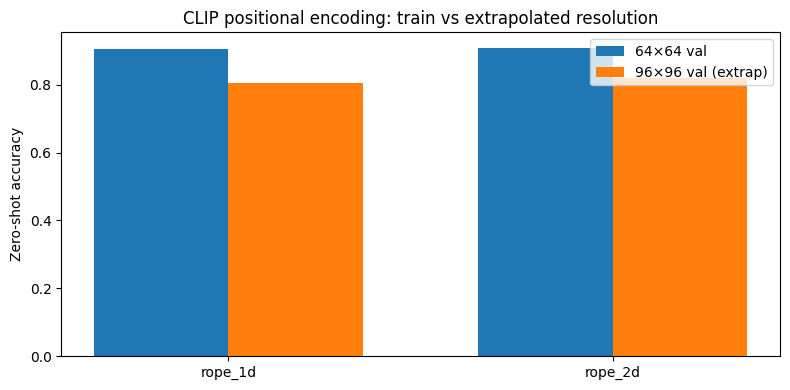

saved runs/figures/clip_posenc_extrapolation.png


In [21]:
run_dirs = {
    # 'learned': RUNS_DIR / 'clip_eurosat',
    'rope_1d': RUNS_DIR / 'clip_eurosat_rope_1d',
    'rope_2d': RUNS_DIR / 'clip_eurosat_rope_2d',
}
rows = []
for label, run_dir in run_dirs.items():
    log_path = run_dir / 'train.log'
    assert log_path.exists(), f'missing {log_path}'
    summary = parse_clip_summary(log_path)
    summary['pos_encoding'] = summary.get('pos_encoding', label)
    rows.append(summary)

df = pd.DataFrame(rows)
cols = ['pos_encoding', 'best_val_zeroshot_acc', 'extrap_val_zeroshot_acc', 'eval_img_size']
print(df[cols])
df['val_drop'] = df['best_val_zeroshot_acc'] - df['extrap_val_zeroshot_acc']

x = np.arange(len(df))
width = 0.35
plt.figure(figsize=(8, 4))
plt.bar(x - width / 2, df['best_val_zeroshot_acc'], width, label='64×64 val')
plt.bar(x + width / 2, df['extrap_val_zeroshot_acc'], width, label='96×96 val (extrap)')
plt.xticks(x, df['pos_encoding'])
plt.ylabel('Zero-shot accuracy')
plt.title('CLIP positional encoding: train vs extrapolated resolution')
plt.legend()
savefig('clip_posenc_extrapolation.png')